# Superstore Dataset Analysis 

This notebook is part of the Introduction to Computer Science & Applications group assignment.

It covers:
- **Q5: Time Series Analysis**

Notebook by Christian Bisrat


Dataset:  
[Kaggle – Superstore Dataset (Final Version)](https://www.kaggle.com/datasets/vivek468/superstore-dataset-final)


In [3]:
# Step 1: Import libraries and set default styles
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose

# Background plotting setup
try:
    sns.set_style('whitegrid')
except Exception:
    try:
        plt.style.use('default')
    except Exception:
        pass

sns.set_context('notebook')

# Helpful display settings
pd.options.display.float_format = '{:,.2f}'.format


In [5]:
# Step 2: Load the Superstore dataset (CSV) and perform initial checks

DATA_PATH = r"../Data/Superstore.csv"  # relative path from notebooks folder

# Load and parse dates
try:
    df = pd.read_csv(DATA_PATH, parse_dates=['Order Date', 'Ship Date'], encoding='ISO-8859-1')
except Exception as e:
    # If parse_dates fails for some reason, load and convert explicitly
    df = pd.read_csv(DATA_PATH, encoding='ISO-8859-1')
    df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')
    df['Ship Date'] = pd.to_datetime(df['Ship Date'], errors='coerce')

# A quick look at the data
print(f"Loaded {len(df)} rows and {len(df.columns)} columns")
df.head().T  # display transposed for readability


Loaded 9994 rows and 21 columns


,0,1,2,3,4
Row ID,1,2,3,4,5
Order ID,CA-2016-152156,CA-2016-152156,CA-2016-138688,US-2015-108966,US-2015-108966
Order Date,2016-11-08 00:00:00,2016-11-08 00:00:00,2016-06-12 00:00:00,2015-10-11 00:00:00,2015-10-11 00:00:00
Ship Date,2016-11-11 00:00:00,2016-11-11 00:00:00,2016-06-16 00:00:00,2015-10-18 00:00:00,2015-10-18 00:00:00
Ship Mode,Second Class,Second Class,Second Class,Standard Class,Standard Class
Customer ID,CG-12520,CG-12520,DV-13045,SO-20335,SO-20335
Customer Name,Claire Gute,Claire Gute,Darrin Van Huff,Sean O'Donnell,Sean O'Donnell
Segment,Consumer,Consumer,Corporate,Consumer,Consumer
Country,United States,United States,United States,United States,United States
City,Henderson,Henderson,Los Angeles,Fort Lauderdale,Fort Lauderdale


In [6]:
# Step 3: Clean columns, set `Order Date` as the index for time-series analysis
# 1) Standardize column names
# 2) Set `Order Date` as the index and sort the DataFrame

df.columns = [c.strip() for c in df.columns]

# Convert string column names to lowercase (for easier reference)
df = df.rename(columns={c: c.lower() for c in df.columns})

# Set 'order date' as index
if 'order date' in df.columns:
    df = df.set_index('order date')
    df = df.sort_index()

# Basic info
print(df.info())
print('\nDate range:', df.index.min(), 'to', df.index.max())
print('\nTotal sales in dataset: ${:,.2f}'.format(df['sales'].sum()))


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 9994 entries, 2014-01-03 to 2017-12-30
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   row id         9994 non-null   int64         
 1   order id       9994 non-null   object        
 2   ship date      9994 non-null   datetime64[ns]
 3   ship mode      9994 non-null   object        
 4   customer id    9994 non-null   object        
 5   customer name  9994 non-null   object        
 6   segment        9994 non-null   object        
 7   country        9994 non-null   object        
 8   city           9994 non-null   object        
 9   state          9994 non-null   object        
 10  postal code    9994 non-null   int64         
 11  region         9994 non-null   object        
 12  product id     9994 non-null   object        
 13  category       9994 non-null   object        
 14  sub-category   9994 non-null   object        
 15  pro

C:\Users\PC\AppData\Local\Temp\ipykernel_14580\1341011218.py:7: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = sales_series.resample('M').sum()
C:\Users\PC\AppData\Local\Temp\ipykernel_14580\1341011218.py:8: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  quarterly_sales = sales_series.resample('Q').sum()


Monthly sales sample:
order date
2014-01-31   14,236.90
2014-02-28    4,519.89
2014-03-31   55,691.01
2014-04-30   28,295.35
2014-05-31   23,648.29
Freq: ME, Name: sales, dtype: float64

Quarterly sales sample:
order date
2014-03-31    74,447.80
2014-06-30    86,538.76
2014-09-30   143,633.21
2014-12-31   179,627.73
2015-03-31    68,851.74
Freq: QE-DEC, Name: sales, dtype: float64


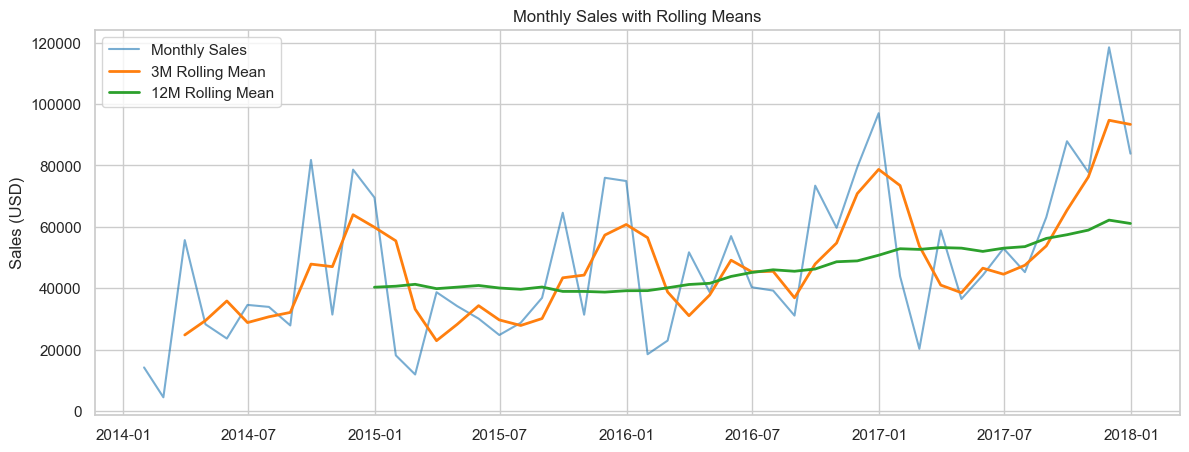

In [7]:
# Step 4: Resample sales by month & quarter and compute rolling averages/growth rates

# Keep only the 'sales' column for time-series aggregation
sales_series = df['sales'].astype(float)

# Resample to monthly and quarterly totals
monthly_sales = sales_series.resample('M').sum()
quarterly_sales = sales_series.resample('Q').sum()

# Rolling means (3-month, 12-month)
monthly_rolling_3 = monthly_sales.rolling(window=3).mean()
monthly_rolling_12 = monthly_sales.rolling(window=12).mean()

# Percentage growth from the previous period (month-over-month and quarter-over-quarter)
monthly_pct_change = monthly_sales.pct_change()
quarterly_pct_change = quarterly_sales.pct_change()

# Summary display
print('Monthly sales sample:')
print(monthly_sales.head())
print('\nQuarterly sales sample:')
print(quarterly_sales.head())

# Basic plot to visualize trends (one line for each series)
plt.figure(figsize=(14,5))
plt.plot(monthly_sales.index, monthly_sales, label='Monthly Sales', alpha=0.6)
plt.plot(monthly_rolling_3.index, monthly_rolling_3, label='3M Rolling Mean', linewidth=2)
plt.plot(monthly_rolling_12.index, monthly_rolling_12, label='12M Rolling Mean', linewidth=2)
plt.title('Monthly Sales with Rolling Means')
plt.ylabel('Sales (USD)')
plt.legend()
plt.show()


In [17]:
# Step 5: Compute numeric metrics to summarize rolling means and trends
from sklearn.linear_model import LinearRegression

# Remove NaNs from monthly_sales if any
ms = monthly_sales.dropna()

# 12-month rolling: start, end, change
r12 = ms.rolling(window=12).mean()
start_r12 = r12.dropna().iloc[0]
end_r12 = r12.dropna().iloc[-1]
abs_change = end_r12 - start_r12
pct_change = (abs_change / start_r12) * 100

# 3-month rolling: compare first full year vs last full year mean
r3 = ms.rolling(window=3).mean()
first_year_mean = r3['2014'].mean()
last_year_mean = r3['2017'].mean()

# Linear trend slope using OLS
X = np.arange(len(ms)).reshape(-1,1)
lr = LinearRegression().fit(X, ms.values)
slope_per_month = lr.coef_[0]

# Average month-over-month growth
mean_mom_growth = monthly_pct_change.mean()

# Display results
print('12M rolling mean: start (first non-NaN): ${:,.2f}, end: ${:,.2f}'.format(start_r12, end_r12))
print('Absolute change in 12M rolling mean: ${:,.2f}, Percent change: {:.2f}%'.format(abs_change, pct_change))
print('\n3M rolling mean average – first year (2014): ${:,.2f}, last year (2017): ${:,.2f}'.format(first_year_mean, last_year_mean))
print('\nLinear trend slope (USD per month): ${:,.2f}'.format(slope_per_month))
print('Average month-over-month growth: {:.2%}'.format(mean_mom_growth))

# Quick note about seasonality: month of highest avg and lowest avg
avg_by_month = ms.groupby(ms.index.month).mean()
max_month = avg_by_month.idxmax()
min_month = avg_by_month.idxmin()
print('\nHighest average sales month (calendar):', max_month)
print('Lowest average sales month (calendar):', min_month)

# Save as textual summary for slides
with open(os.path.join(visuals_dir, 'rolling_summary.txt'), 'w') as f:
    f.write(f"12M rolling mean start: ${start_r12:,.2f}\n")
    f.write(f"12M rolling mean end: ${end_r12:,.2f}\n")
    f.write(f"12M rolling mean change: ${abs_change:,.2f} ({pct_change:.2f}%)\n")
    f.write(f"3M rolling mean first year vs last year: ${first_year_mean:,.2f} vs ${last_year_mean:,.2f}\n")
    f.write(f"Linear trend slope (USD/month): ${slope_per_month:,.2f}\n")
    f.write(f"Avg month-over-month growth: {mean_mom_growth:.2%}\n")
    f.write(f"Highest avg month: {max_month}, Lowest avg month: {min_month}\n")
print('Saved `rolling_summary.txt` to visuals folder')

12M rolling mean: start (first non-NaN): $40,353.96, end: $61,101.27
Absolute change in 12M rolling mean: $20,747.31, Percent change: 51.41%

3M rolling mean average – first year (2014): $40,067.63, last year (2017): $60,748.59

Linear trend slope (USD per month): $902.01
Average month-over-month growth: 41.56%

Highest average sales month (calendar): 11
Lowest average sales month (calendar): 2
Saved `rolling_summary.txt` to visuals folder


# What the rolling means show (Simple interpretation)

##### .12-month moving average shows steady uplift: from ~ $40k to ~ $61k per month (51% increase).
##### .3-month moving average highlights frequent short-term peaks, seful for short-term operational planning.
##### .Highest monthly demand in November; lowest in February, plan promotions and stock accordingly.
##### . Increasing slope (~$902/month) suggests consistent growth, consider scaling marketing and supply resources.


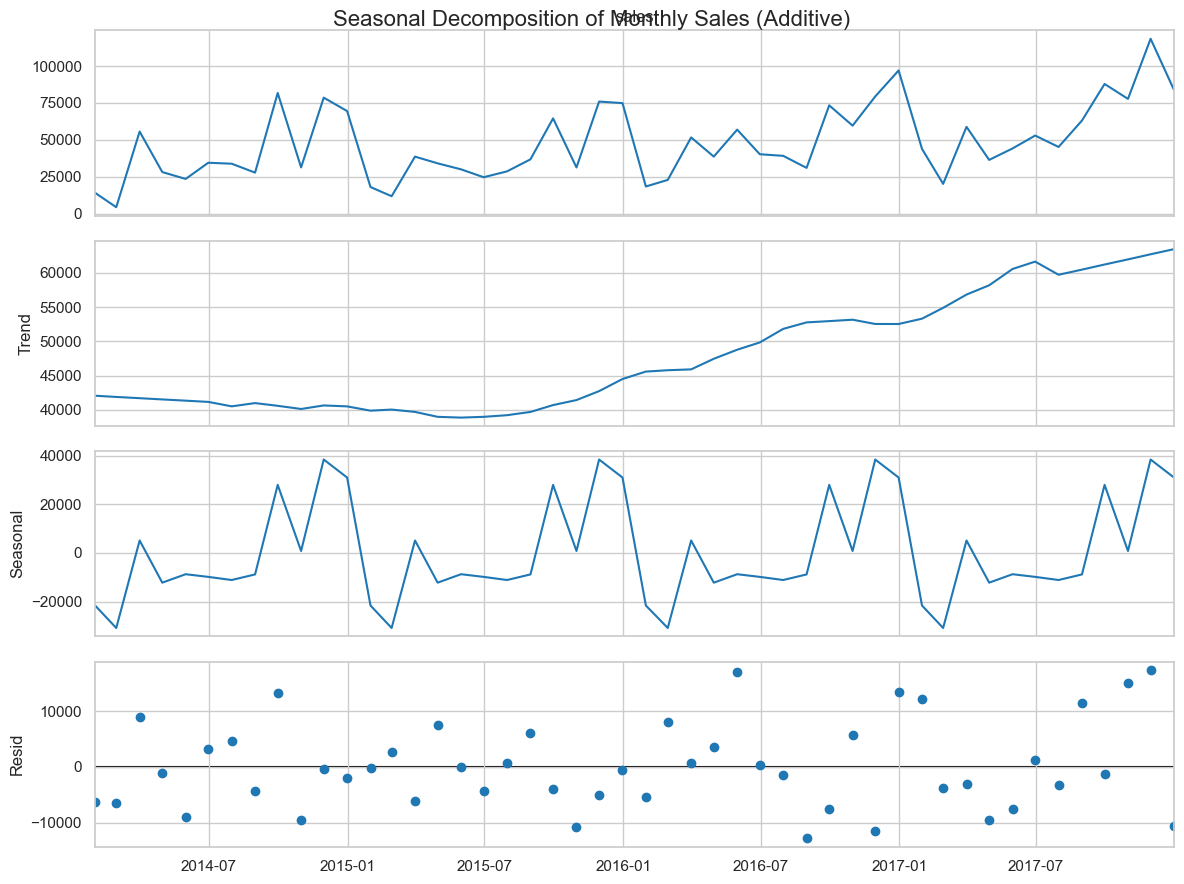

<Figure size 1400x400 with 0 Axes>

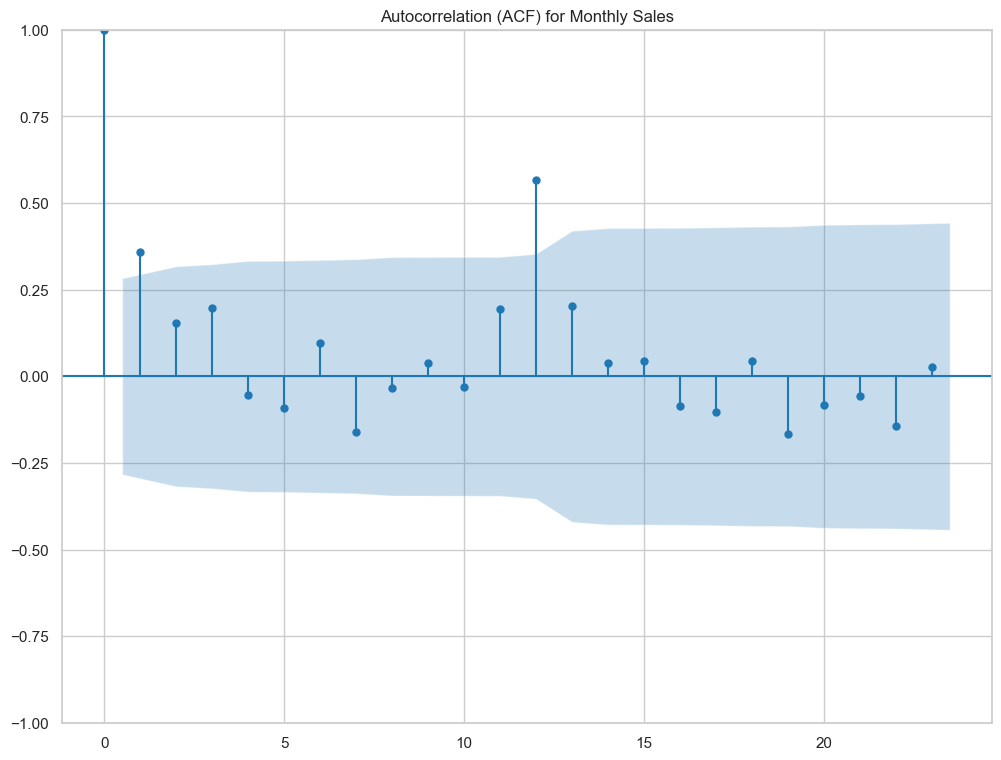

<Figure size 1400x400 with 0 Axes>

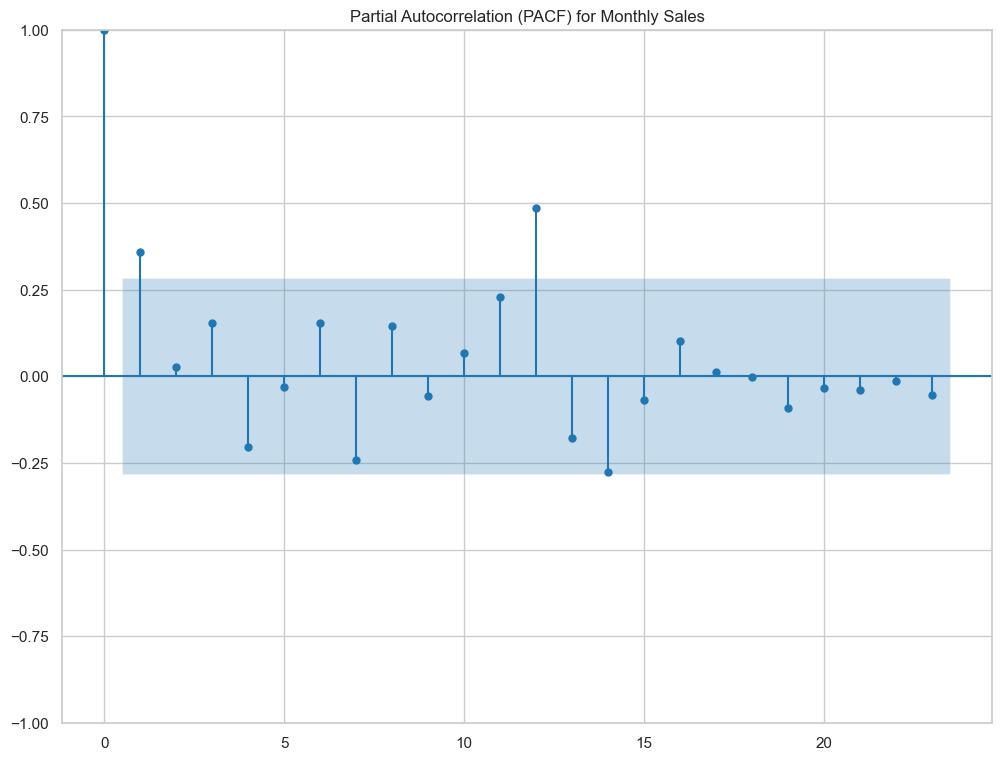

In [18]:
# Step 6: Seasonality and decomposition

# Seasonal decomposition (additive) with 12-month periodicity
decomp = seasonal_decompose(monthly_sales, model='additive', period=12, extrapolate_trend='freq')

plt.rcParams['figure.figsize'] = (12, 9)
fig = decomp.plot()
plt.suptitle('Seasonal Decomposition of Monthly Sales (Additive)', fontsize=16)
plt.show()

# ACF and PACF to inspect autocorrelation/seasonality
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
n_obs = len(monthly_sales.dropna())
# Choose lags <= 50% of sample size to satisfy pacf constraints
max_lags = max(1, min(36, n_obs // 2 - 1))

plt.figure(figsize=(14,4))
plot_acf(monthly_sales.dropna(), lags=max_lags, alpha=0.05)
plt.title('Autocorrelation (ACF) for Monthly Sales')
plt.show()

plt.figure(figsize=(14,4))
plot_pacf(monthly_sales.dropna(), lags=max_lags, alpha=0.05, method='ywm')
plt.title('Partial Autocorrelation (PACF) for Monthly Sales')
plt.show()


# Interpretation: Seasonality & decomposition (Observed / Trend / Seasonal / Residual)

- Observed (raw series): shows recurring peaks and troughs each year and increasing amplitude later in the series, monthly sales clearly increase over 2014–2017.

- Trend (12-month moving average): the trend line confirms a steady upward direction in sales (long-term growth). The slope indicates an average increase of about $900 per month.

- Seasonal component: there is a strong, repeatable annual pattern; months like November consistently show above-average sales (likely holiday-related), while February is consistently lower.

- Residual (irregulars/outliers): the residuals are mostly centered around zero but include occasional, large spikes, these likely represent one-off large orders, campaigns, or anomalies that are not explained by trend or seasonality.

- ACF/PACF summary: the ACF shows strong correlation at lag 12, confirming yearly seasonality; the PACF shows short-term autocorrelation (lag 1) and a seasonal partial spike near lag 12 — this suggests an autoregressive/seasonal AR component is useful when modeling.

- Business implications:
  1) Plan resources (inventory, staffing, marketing) for higher-demand months (Nov/Q4).  
  2) Use promotions or campaigns to lift low months (e.g., Feb) and smooth demand.  
  3) For forecasting, use models that incorporate seasonality (SARIMA, Prophet) and consider transforming or robustifying data if residual variance increases over time.

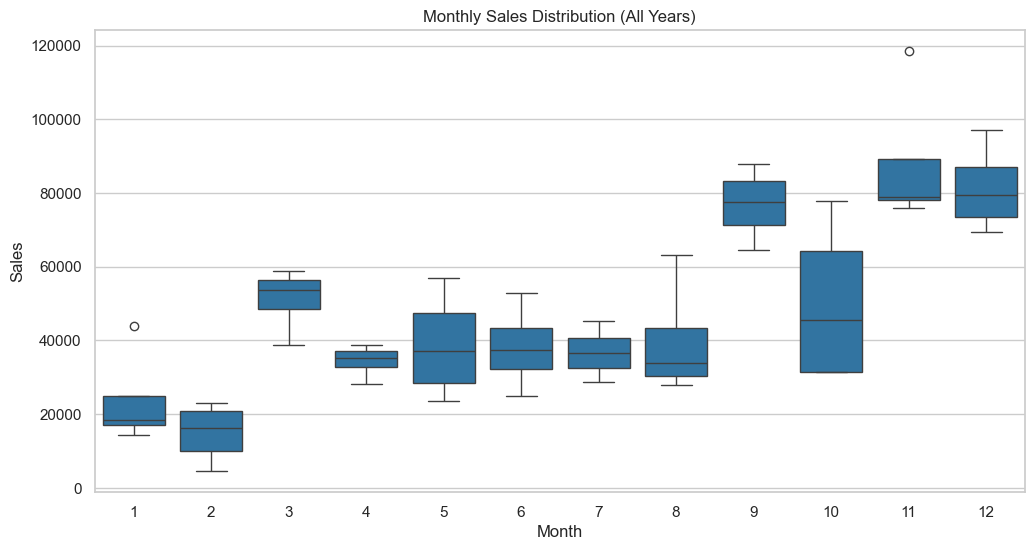

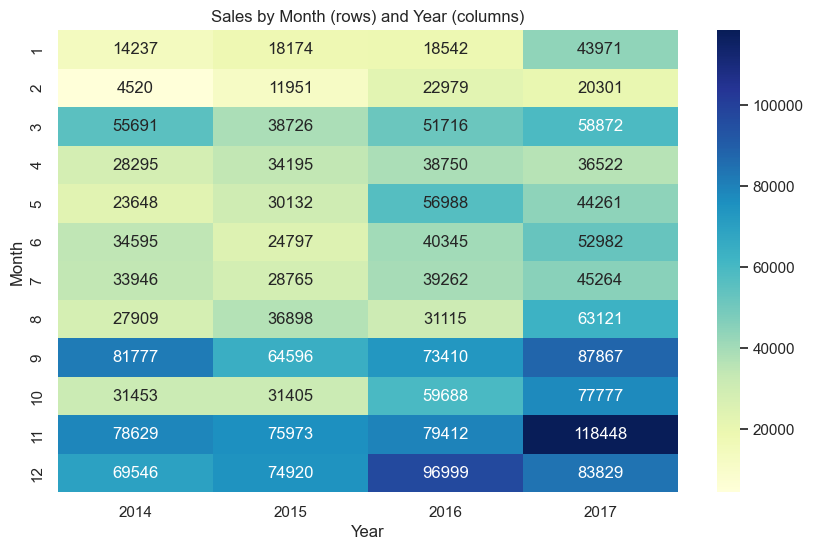

In [22]:
# Step 7: Visual checks for seasonality – boxplots and heatmap by month & year

# Create a month and year column
monthly_df = monthly_sales.to_frame(name='sales').copy()
monthly_df['year'] = monthly_df.index.year
monthly_df['month'] = monthly_df.index.month

# Boxplot of sales by month (to show monthly seasonality)
plt.figure(figsize=(12,6))
sns.boxplot(data=monthly_df, x='month', y='sales')
plt.title('Monthly Sales Distribution (All Years)')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.show()

# Heatmap of month vs year
pivot = monthly_df.pivot_table(index='month', columns='year', values='sales', aggfunc='sum')
plt.figure(figsize=(10,6))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlGnBu')
plt.title('Sales by Month (rows) and Year (columns)')
plt.xlabel('Year')
plt.ylabel('Month')
plt.show()


# Interpretation: Monthly Sales Distribution (Boxplot) & Sales by Month/Year (Heatmap)

- Monthly Sales Distribution (Boxplot):
  - The boxplot shows the distribution of monthly totals across years for each calendar month. Months like **November and December** have the highest median and the largest spread (interquartile range), indicating both consistently high demand and larger variability (likely due to promotions, holiday sales, or major orders).
  - **February** shows the lowest median and relatively low spread; a low-demand, stable month.
  - Outliers appear in many months (single large monthly totals). These should be investigated as potential one-off large orders or campaign-driven spikes and treated carefully when forecasting.

- Sales by Month / Year (Heatmap):
  - The heatmap shows absolute monthly sales (rows = month, columns = year). Colors darken in later years (2016–2017), confirming the upward trend seen in the decomposition plots.
  - Consistently darker cells appear in **November** and **December** across years; again showing seasonal high demand in late-year months.
  - Some months show clear year-over-year increases (e.g., November and August in some years), which helps identify months where promotions or market growth might be driving stronger results.

- Business Takeaways:
  1. **Q4 (Nov–Dec) is the most important period** for revenue—plan inventory, staffing, and marketing spends to maximize conversion during this high-revenue/variable period.
  2. **Slow months (e.g., Feb)** are good candidates for targeted promotions to smooth demand, consider bundling or discounts during those months.
  3. **High variability months** (wide box ranges) signal risk: consider conservative inventory or contingency plans for returns/fulfillment during those months.
  4. When forecasting, use the seasonal pattern confirmed by the heatmap and boxplot to set monthly expected baselines and confidence intervals.

C:\Users\PC\AppData\Local\Temp\ipykernel_14580\2566700465.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  cat_monthly = df.groupby([pd.Grouper(freq='M'), 'category'])['sales'].sum().unstack('category')


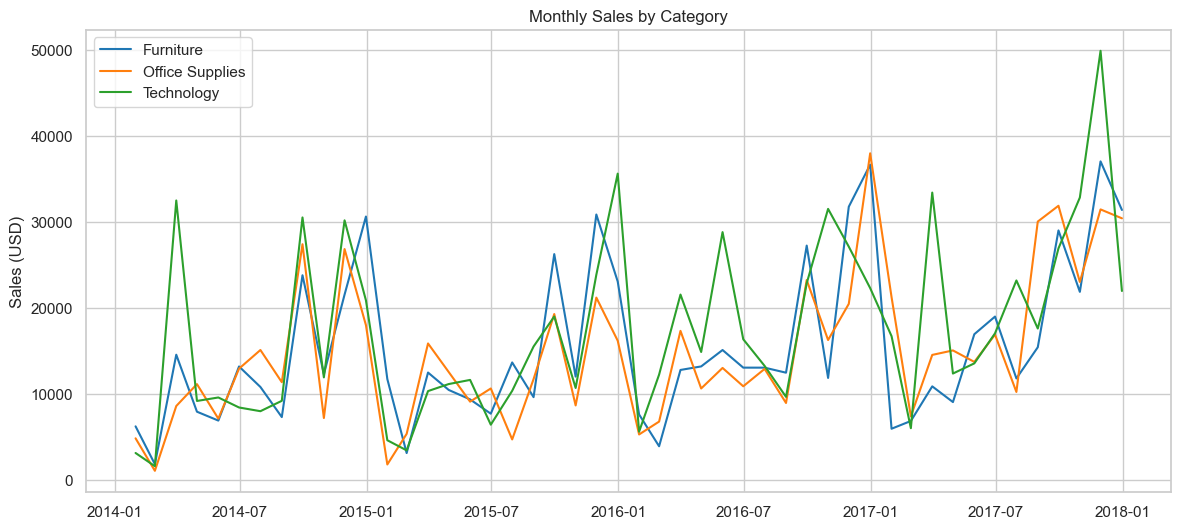

C:\Users\PC\AppData\Local\Temp\ipykernel_14580\2566700465.py:15: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  region_monthly = df.groupby([pd.Grouper(freq='M'), 'region'])['sales'].sum().unstack('region')


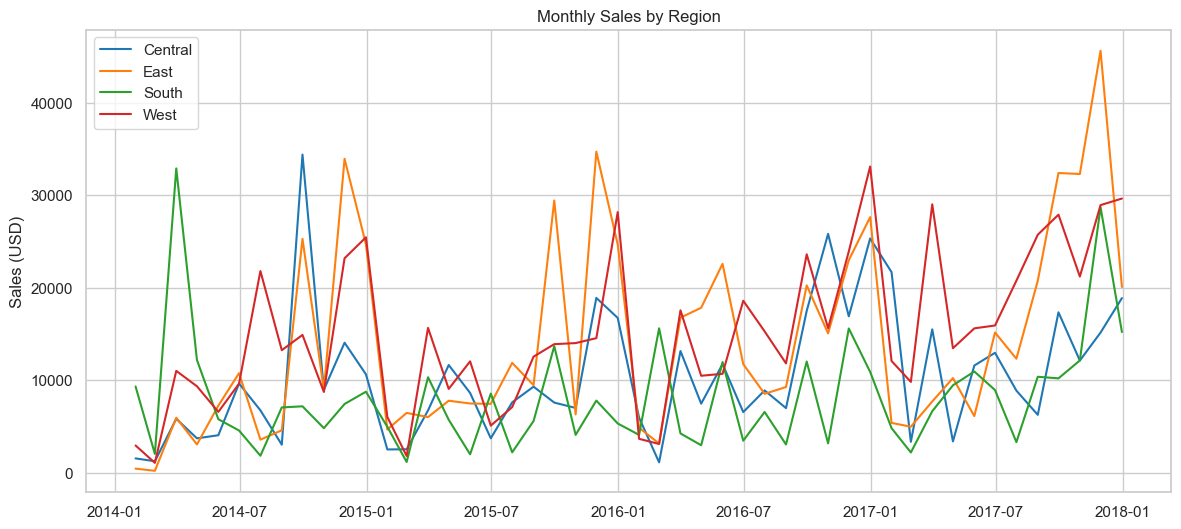

In [23]:
# Step 8: Dashboard-like visuals—trends by category and region

# Monthly sales per `category`
cat_monthly = df.groupby([pd.Grouper(freq='M'), 'category'])['sales'].sum().unstack('category')

plt.figure(figsize=(14,6))
for c in cat_monthly.columns:
    plt.plot(cat_monthly.index, cat_monthly[c], label=c)
plt.title('Monthly Sales by Category')
plt.ylabel('Sales (USD)')
plt.legend()
plt.show()

# Monthly sales per `region`
region_monthly = df.groupby([pd.Grouper(freq='M'), 'region'])['sales'].sum().unstack('region')

plt.figure(figsize=(14,6))
for r in region_monthly.columns:
    plt.plot(region_monthly.index, region_monthly[r], label=r)
plt.title('Monthly Sales by Region')
plt.ylabel('Sales (USD)')
plt.legend()
plt.show()


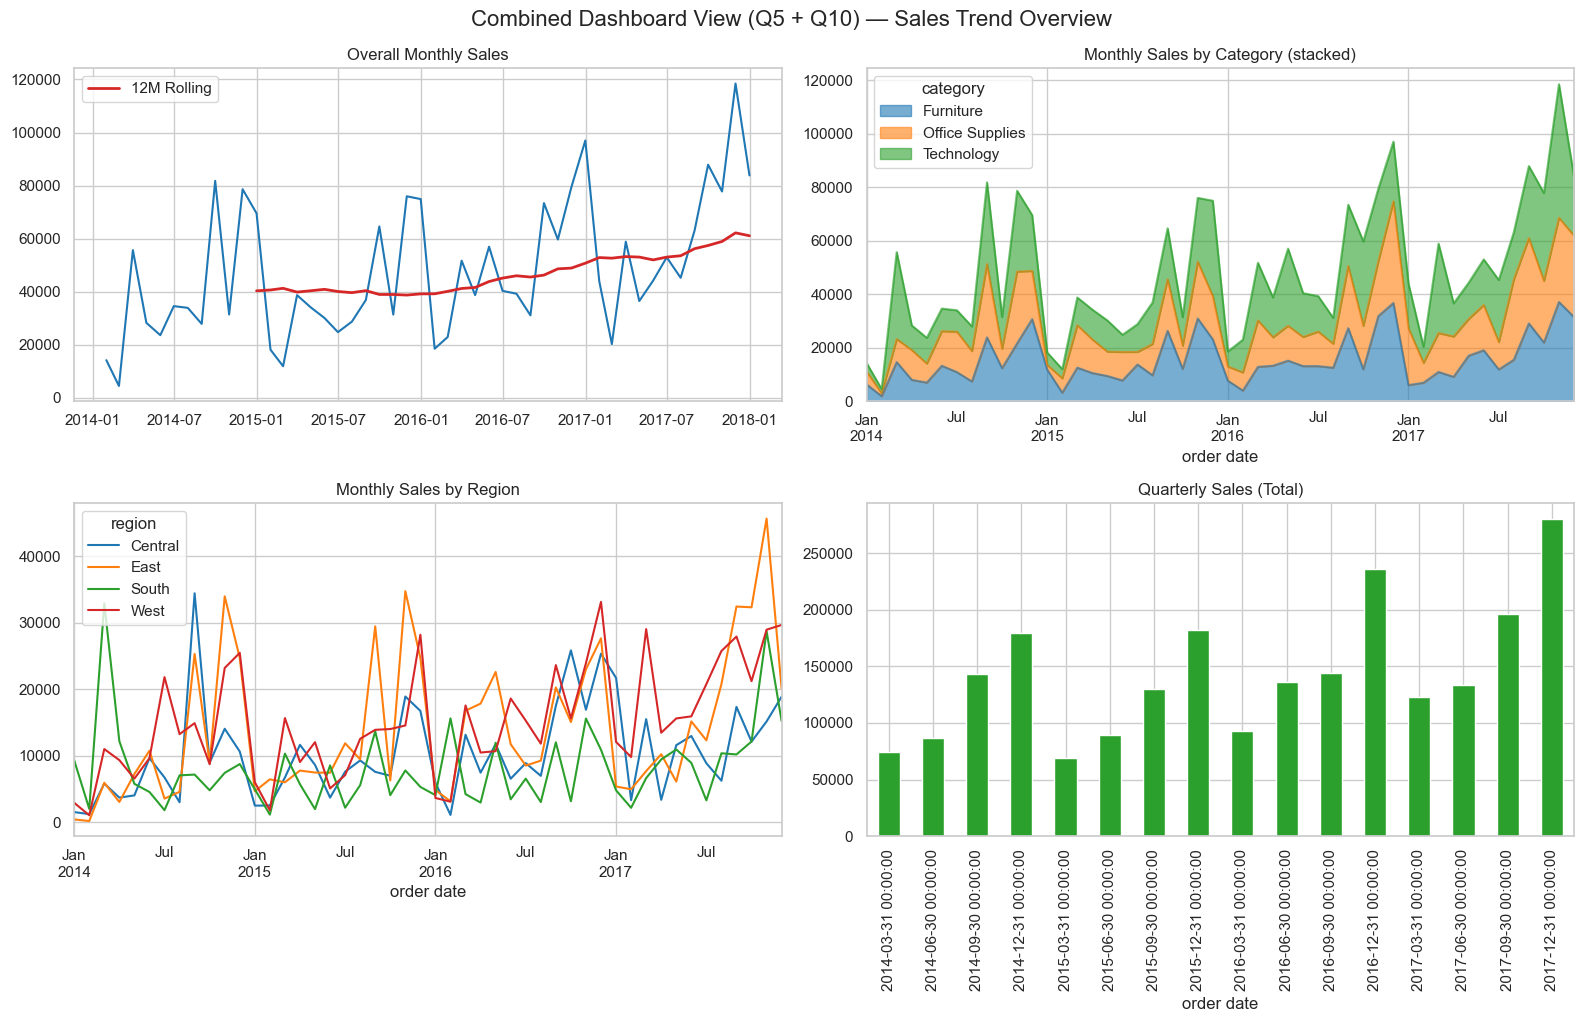

Saved dashboard figure to: c:\Users\PC\Downloads\intro-to-cs\Superstore-analysis\visuals\dashboard_sales_overview.png


In [24]:
# Step 9: Create a dashboard figure combining multiple visuals and save to `visuals/` folder

# Create a 2x2 grid of plots: overall monthly, category, region, quarterly bars
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1) Overall monthly sales
axes[0,0].plot(monthly_sales.index, monthly_sales, color='tab:blue')
axes[0,0].plot(monthly_rolling_12.index, monthly_rolling_12, color='tab:red', linewidth=2, label='12M Rolling')
axes[0,0].set_title('Overall Monthly Sales')
axes[0,0].legend()

# 2) Monthly by Category (stacked area for clarity)
cat_monthly.plot(ax=axes[0,1], kind='area', stacked=True, legend=True, alpha=0.6)
axes[0,1].set_title('Monthly Sales by Category (stacked)')

# 3) Monthly by Region
region_monthly.plot(ax=axes[1,0])
axes[1,0].set_title('Monthly Sales by Region')

# 4) Quarterly bar plot
quarterly_sales.plot(kind='bar', ax=axes[1,1], color='tab:green')
axes[1,1].set_title('Quarterly Sales (Total)')

plt.tight_layout()
plt.suptitle('Combined Dashboard View (Q5 + Q10) — Sales Trend Overview', fontsize=16, y=1.02)
plt.show()

# Save the image for slides if folder exists
import os
visuals_dir = os.path.abspath(os.path.join('..', 'visuals'))
if not os.path.exists(visuals_dir):
    os.makedirs(visuals_dir)

fig_filename = os.path.join(visuals_dir, 'dashboard_sales_overview.png')
fig.savefig(fig_filename, bbox_inches='tight')
print('Saved dashboard figure to:', fig_filename)


In [25]:
# Step 10: Save separate images for each visualization (Matplotlib) — one chart per file
import os
visuals_dir = os.path.abspath(os.path.join('..', 'visuals'))

# Ensure visuals dir exists
if not os.path.exists(visuals_dir):
    os.makedirs(visuals_dir)

# 1) Overall monthly sales with rolling means
fig, ax = plt.subplots(figsize=(12,5))
ax.plot(monthly_sales.index, monthly_sales, label='Monthly Sales', alpha=0.6)
ax.plot(monthly_rolling_3.index, monthly_rolling_3, label='3M Rolling Mean', linewidth=2)
ax.plot(monthly_rolling_12.index, monthly_rolling_12, label='12M Rolling Mean', linewidth=2)
ax.set_title('Monthly Sales with Rolling Means')
ax.set_ylabel('Sales (USD)')
ax.legend()
fig.savefig(os.path.join(visuals_dir,'monthly_sales_with_rolling.png'), bbox_inches='tight')
plt.close(fig)

# 2) Quarterly sales bar chart
fig, ax = plt.subplots(figsize=(10,5))
quarterly_sales.plot(kind='bar', color='tab:green', ax=ax)
ax.set_title('Quarterly Sales (Total)')
ax.set_ylabel('Sales (USD)')
fig.savefig(os.path.join(visuals_dir,'quarterly_sales.png'), bbox_inches='tight')
plt.close(fig)

# 3) Monthly sales by category
fig, ax = plt.subplots(figsize=(12,5))
for c in cat_monthly.columns:
    ax.plot(cat_monthly.index, cat_monthly[c], label=c)
ax.set_title('Monthly Sales by Category')
ax.set_ylabel('Sales (USD)')
ax.legend()
fig.savefig(os.path.join(visuals_dir,'monthly_by_category.png'), bbox_inches='tight')
plt.close(fig)

# 4) Monthly sales by region
fig, ax = plt.subplots(figsize=(12,5))
for r in region_monthly.columns:
    ax.plot(region_monthly.index, region_monthly[r], label=r)
ax.set_title('Monthly Sales by Region')
ax.set_ylabel('Sales (USD)')
ax.legend()
fig.savefig(os.path.join(visuals_dir,'monthly_by_region.png'), bbox_inches='tight')
plt.close(fig)

# 5) Seasonal decomposition saved separately
fig = decomp.plot()
fig.suptitle('Seasonal Decomposition of Monthly Sales (Additive)', fontsize=16)
fig.savefig(os.path.join(visuals_dir,'seasonal_decomposition.png'), bbox_inches='tight')
plt.close(fig)

# 6) ACF & PACF
fig = plt.figure(figsize=(12,4))
plot_acf(monthly_sales.dropna(), lags=max_lags, alpha=0.05)
plt.title('Autocorrelation (ACF) for Monthly Sales')
plt.savefig(os.path.join(visuals_dir,'acf_monthly_sales.png'), bbox_inches='tight')
plt.close()

fig = plt.figure(figsize=(12,4))
plot_pacf(monthly_sales.dropna(), lags=max_lags, alpha=0.05, method='ywm')
plt.title('Partial Autocorrelation (PACF) for Monthly Sales')
plt.savefig(os.path.join(visuals_dir,'pacf_monthly_sales.png'), bbox_inches='tight')
plt.close()

# 7) Boxplot (monthly distributions)
fig, ax = plt.subplots(figsize=(12,5))
sns.boxplot(data=monthly_df, x='month', y='sales', ax=ax)
ax.set_title('Monthly Sales Distribution (All Years)')
fig.savefig(os.path.join(visuals_dir,'boxplot_monthly_sales.png'), bbox_inches='tight')
plt.close(fig)

# 8) Heatmap (month-year pivot)
fig, ax = plt.subplots(figsize=(10,6))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlGnBu', ax=ax)
ax.set_title('Sales by Month (rows) and Year (columns)')
fig.savefig(os.path.join(visuals_dir,'heatmap_month_year_sales.png'), bbox_inches='tight')
plt.close(fig)

print('Saved individual chart images to the visuals folder')


Saved individual chart images to the visuals folder


<Figure size 1200x400 with 0 Axes>

<Figure size 1200x400 with 0 Axes>

In [28]:
# Step 11: Quantitative summary: key numbers and seasonality summary

# 1) Monthly average sales per month-of-year (to identify seasonality pattern)
avg_by_month = monthly_df.groupby('month')['sales'].mean()
max_month = avg_by_month.idxmax()
min_month = avg_by_month.idxmin()

# 2) Average monthly growth and last year's growth
mean_mom_growth = monthly_pct_change.mean()
last_month_growth = monthly_pct_change.dropna().iloc[-1]

# 3) Top category and top region overall
top_category = df.reset_index().groupby('category')['sales'].sum().sort_values(ascending=False).head(1)
top_region = df.reset_index().groupby('region')['sales'].sum().sort_values(ascending=False).head(1)

# Print readable summaries
print('--- Key Summary ---')
print('Dataset covers dates from', df.index.min().strftime('%Y-%m-%d'), 'to', df.index.max().strftime('%Y-%m-%d'))
print('Total Sales: ${:,.2f}'.format(df['sales'].sum()))
print('\nAverage sales by calendar month:')
print(avg_by_month)
print(f'Highest average sales month: {max_month} (month number), lowest average month: {min_month} (month number)')
print('\nAverage month-over-month growth:', '{:.2%}'.format(mean_mom_growth))
print('Most recent month-over-month growth:', '{:.2%}'.format(last_month_growth))
print('\nTop category overall:')
print(top_category)
print('\nTop region overall:')
print(top_region)

# Save the results in a small CSV for inclusion in the report
summary_df = pd.DataFrame({'avg_sales_by_month': avg_by_month})
summary_df.to_csv(os.path.join(visuals_dir, 'avg_sales_by_month.csv'))
print('Saved `avg_sales_by_month.csv` to report folder')


--- Key Summary ---
Dataset covers dates from 2014-01-03 to 2017-12-30
Total Sales: $2,297,200.86

Average sales by calendar month:
month
1    23,731.21
2    14,937.81
3    51,251.37
4    34,440.53
5    38,757.20
6    38,179.67
7    36,809.52
8    39,761.02
9    76,912.49
10   50,080.75
11   88,115.27
12   81,323.38
Name: sales, dtype: float64
Highest average sales month: 11 (month number), lowest average month: 2 (month number)

Average month-over-month growth: 41.56%
Most recent month-over-month growth: -29.23%

Top category overall:
category
Technology   836,154.03
Name: sales, dtype: float64

Top region overall:
region
West   725,457.82
Name: sales, dtype: float64
Saved `avg_sales_by_month.csv` to report folder
